In [14]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

## Computational environment and software versions
Records the Python and library versions used, for reproducibility and the operational-cost reporting in the manuscript.

In [15]:
import sys, platform
import numpy, xarray, matplotlib
print("Python      :", sys.version.split()[0])
print("Platform    :", platform.platform())
print("Processor   :", platform.processor())
print("numpy       :", numpy.__version__)
print("xarray      :", xarray.__version__)
print("matplotlib  :", matplotlib.__version__)
try:
    import netCDF4; print("netCDF4     :", netCDF4.__version__)
except Exception: pass
try:
    import h5netcdf; print("h5netcdf    :", h5netcdf.__version__)
except Exception: pass

Python      : 3.13.9
Platform    : Windows-11-10.0.26100-SP0
Processor   : Intel64 Family 6 Model 181 Stepping 0, GenuineIntel
numpy       : 2.3.5
xarray      : 2025.10.1
matplotlib  : 3.10.6
netCDF4     : 1.7.4
h5netcdf    : 1.8.1


Load Data

In [16]:
STNS = np.loadtxt("../DATA/Stations.txt",dtype='U2')
VNS = np.loadtxt("../DATA/Products.txt",dtype='<U10')

STN_DATA = xr.open_dataarray("../DATA/STN_DATA.nc")
STN_ERR = xr.open_dataarray("../DATA/STN_ERR.nc")
STN_BIAS = xr.open_dataarray("../DATA/STN_BIAS.nc")
STN_RMSE = xr.open_dataarray("../DATA/STN_RMSE.nc")
STN_CC = xr.open_dataarray("../DATA/STN_CC.nc")

## Input data volume
Total on-disk size of the pre-aggregated inputs consumed by the AB stage (8-day ET estimates and error fields for all stations and products).

In [17]:
import os
files = ["STN_DATA.nc", "STN_ERR.nc", "STN_BIAS.nc", "STN_RMSE.nc", "STN_CC.nc"]
total = 0.0
for f in files:
    p = os.path.join("../DATA", f)
    if os.path.exists(p):
        sz = os.path.getsize(p) / 1e6
        total += sz
        print(f"{f:14s} {sz:8.2f} MB")
print(f"{'TOTAL':14s} {total:8.2f} MB")

STN_DATA.nc        0.57 MB
STN_ERR.nc         0.57 MB
STN_BIAS.nc        0.01 MB
STN_RMSE.nc        0.01 MB
STN_CC.nc          0.01 MB
TOTAL              1.16 MB


Drop PM and TH Products

In [18]:
O = STN_DATA.loc[dict(Product="PM")]
REMOTE = STN_DATA.drop_sel(Product=["PM", "TH"])
ERR_REMOTE = STN_ERR.drop_sel(Product=["PM", "TH"])

Window size  1: Mean error (ME) = 0.039740
Window size  2: Mean error (ME) = 0.031830
Window size  3: Mean error (ME) = 0.030023
Window size  4: Mean error (ME) = 0.031217
Window size  5: Mean error (ME) = 0.033433
Window size  6: Mean error (ME) = 0.035026
Window size  7: Mean error (ME) = 0.041723
Window size  8: Mean error (ME) = 0.042057
Window size  9: Mean error (ME) = 0.050421
Window size 10: Mean error (ME) = 0.056016
Window size 11: Mean error (ME) = 0.063102
Window size 12: Mean error (ME) = 0.066284
Window size 13: Mean error (ME) = 0.069491
Window size 14: Mean error (ME) = 0.073887
Window size 15: Mean error (ME) = 0.082127
Window size 16: Mean error (ME) = 0.085405
Window size 17: Mean error (ME) = 0.091393
Window size 18: Mean error (ME) = 0.098549
Window size 19: Mean error (ME) = 0.107196
Window size 20: Mean error (ME) = 0.114115
Window size 21: Mean error (ME) = 0.111009
Window size 22: Mean error (ME) = 0.124203
Window size 23: Mean error (ME) = 0.159458
Window size

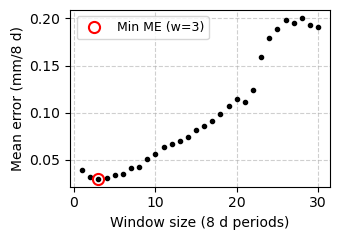

In [19]:
# Set up the figure
plt.figure(figsize=(3.5, 2.5))

errs = []         
window_sizes = []  

for iw in range(1, 31):
    STN_WM = ERR_REMOTE.rolling(datetime=iw, center=False).mean()
    STN_AB = REMOTE[:, :, iw:] - STN_WM[:, :, iw-1:-1].values
    STN_AB = STN_AB.where(STN_AB >= 0, 0)
    STN_AB_ERR = STN_AB - O[:, iw:]

    # ME
    err_iw = float(np.mean(STN_AB_ERR))
    window_sizes.append(iw)
    errs.append(err_iw)

    # smaller black circle markers
    plt.plot(iw, err_iw, 'ko', markersize=3)

# Find best window size based on minimum ME
best_idx = int(np.argmin(errs))
best_iw = window_sizes[best_idx]
best_err = errs[best_idx]

# Red circle around the best point 
plt.plot(
    best_iw, best_err,
    marker='o', linestyle='None',
    markerfacecolor='none', markeredgecolor='red',
    markeredgewidth=1.5, markersize=8, zorder=5,
    label=f"Min ME (w={best_iw})"
)

# Print errors for each window size
for iw, e in zip(window_sizes, errs):
    print(f"Window size {iw:2d}: Mean error (ME) = {e:.6f}")

print(f"\nBest window size = {best_iw} (minimum ME = {best_err:.6f})")

plt.grid(True, linestyle='--', alpha=0.6)
plt.ylabel("Mean error (mm/8 d)", fontsize=10)
plt.xlabel("Window size (8 d periods)", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.legend(fontsize=9, loc="best")

plt.tight_layout()
plt.savefig("WindowSize_AdaptiveBias.png", dpi=300, bbox_inches='tight')


## Calibration cost — AB window sweep (one-time)
Times the full `w = 1..30` sweep used to select the AB window (Figure 4). This is a **one-time calibration cost**, incurred at setup or when recalibrating for a new region/regime — not the recurring operational cost.

In [20]:
import time
import numpy as np

N_REPEATS = 5
ab_sweep_times = []
for rep in range(N_REPEATS):
    t0 = time.perf_counter()
    errs = []
    for iw in range(1, 31):
        STN_WM = ERR_REMOTE.rolling(datetime=iw, center=False).mean()
        STN_AB = REMOTE[:, :, iw:] - STN_WM[:, :, iw-1:-1].values
        STN_AB = STN_AB.where(STN_AB >= 0, 0)
        STN_AB_ERR = STN_AB - O[:, iw:]
        errs.append(float(np.mean(STN_AB_ERR)))
    ab_sweep_times.append(time.perf_counter() - t0)

ab_sweep_times = np.array(ab_sweep_times)
print(f"AB window sweep (w=1..30), {N_REPEATS} repeats:")
print(f"  mean  = {ab_sweep_times.mean():.3f} s")
print(f"  range = [{ab_sweep_times.min():.3f}, {ab_sweep_times.max():.3f}] s")

AB window sweep (w=1..30), 5 repeats:
  mean  = 0.310 s
  range = [0.260, 0.351] s


## Production cost — AB computation (recurring, iw=3)
Times the operational AB path at the chosen window `iw=3`. This is the **recurring per-update cost**. Inputs are already in memory from the Load Data cell, so timing is scoped to the AB computation itself (excludes one-time data extraction and 8-day aggregation, which are upstream).

In [21]:
import time
import numpy as np

N_REPEATS = 5
ab_times = []
for rep in range(N_REPEATS):
    t0 = time.perf_counter()
    iw = 3
    STN_WM = ERR_REMOTE.rolling(datetime=iw, center=False).mean()
    STN_AB = REMOTE[:, :, iw:] - STN_WM[:, :, iw-1:-1].values
    STN_AB = STN_AB.where(STN_AB >= 0, 0)
    AB_d1 = STN_AB.datetime[0].values
    AB_dn = STN_AB.datetime[-1].values
    STN_AB_ERR = STN_AB.sel(datetime=slice(AB_d1, AB_dn)) - O.sel(datetime=slice(AB_d1, AB_dn))
    ab_times.append(time.perf_counter() - t0)

ab_times = np.array(ab_times)
n_stn = len(STNS)
print(f"AB production (iw=3), {N_REPEATS} repeats:")
print(f"  mean        = {ab_times.mean()*1000:.1f} ms")
print(f"  range       = [{ab_times.min()*1000:.1f}, {ab_times.max()*1000:.1f}] ms")
print(f"  per station = {ab_times.mean()/n_stn*1000:.2f} ms  (n={n_stn} stations)")

AB production (iw=3), 5 repeats:
  mean        = 11.8 ms
  range       = [9.6, 14.0] ms
  per station = 0.56 ms  (n=21 stations)


In [22]:
iw=3
STN_WM = ERR_REMOTE.rolling(datetime=iw, center=False).mean()
STN_AB = REMOTE[:,:,iw:] - STN_WM[:,:,iw-1:-1].values
STN_AB = STN_AB.where(STN_AB >= 0, 0)

In [23]:
AB_d1=STN_AB.datetime[0].values
AB_dn=STN_AB.datetime[-1].values

In [24]:
STN_AB_ERR = STN_AB.sel(datetime=slice(AB_d1, AB_dn)) - O.sel(datetime=slice(AB_d1, AB_dn))

In [25]:
STN_AB.to_netcdf("../DATA/STN_AB.nc")
STN_AB_ERR.to_netcdf("../DATA/STN_AB_ERR.nc")

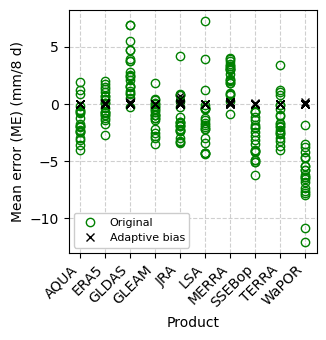

In [26]:
myfig, myax = plt.subplots(figsize=[3.5,3.5])

for i in range(0, len(STNS)):
    ERR_REMOTE.loc[dict(Station=STNS[i])].mean(dim=["datetime"]).plot(
        ax=myax, marker="o", linestyle="", fillstyle="none", color="green",
        label="Original" if i == 0 else "_nolegend_"
    )
    
    STN_AB_ERR.loc[dict(Station=STNS[i])].mean(dim=["datetime"]).plot(
        ax=myax, marker="x", linestyle="", fillstyle="none", color="black",
        label="Adaptive bias" if i == 0 else "_nolegend_"
    )

plt.grid(True, linestyle='--', alpha=0.6)
plt.ylabel("Mean Absolute Bias", fontsize=10)
plt.xlabel("Product", fontsize=10)

# Improved x-tick handling
plt.xticks(fontsize=10, rotation=45, ha='right')  
plt.yticks(fontsize=10)    

myax.set_title("")
myax.tick_params(axis='x', labelrotation=45)
myax.set_ylabel("Mean error (ME) (mm/8 d)")

# Add legend
myax.legend(loc="lower left", fontsize=8, frameon=True, framealpha=1)

plt.tight_layout()  

plt.savefig("ET4I_AdaptiveBias.png", dpi=300, bbox_inches='tight')